# 🔍 Notebook 01: Data Exploration & Statistical Audit
**โครงการ**: Used Car Analytics (Data Warehouse & ETL Pipeline)

สมุดบันทึกนี้ออกแบบมาเพื่อทำการ **Explore & Audit** ข้อมูลดิบจากทั้ง 3 แหล่งข้อมูล (Kaidee Auto JSON, One2car Multi-CSV, และ US Sales CSV) โดยเน้นตรวจจับ Skewness, Outliers และ Typo ของข้อมูลดิบอย่างละเอียด 100%

---

In [1]:
import os
import glob
import json
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

print("✅ Setup Completed Successfully!")

✅ Setup Completed Successfully!


### 1. Load Raw Data (All 3 Data Sources)

In [2]:
# 1. Kaidee JSON
json_path = os.path.abspath("../../01_Raw_Data/kaidee/kaidee_cars_detail.json")
if not os.path.exists(json_path): json_path = os.path.abspath("01_Raw_Data/kaidee/kaidee_cars_detail.json")
with open(json_path, 'r', encoding='utf-8') as f:
    df_kaidee_raw = pd.DataFrame(json.load(f))

# 2. One2car Multi-CSV
one2car_dir = os.path.abspath("../../01_Raw_Data/one2car")
if not os.path.exists(one2car_dir): one2car_dir = os.path.abspath("01_Raw_Data/one2car")
csv_files = sorted(glob.glob(os.path.join(one2car_dir, "*.csv")))
def std_col(df):
    return df.rename(columns={"data": "car_title", "data2": "description", "data3": "mileage", "data4": "location", "data6": "car_model", "data16": "transmission"})
df_one2car_raw = pd.concat([std_col(pd.read_csv(f)) for f in csv_files], ignore_index=True)

# 3. US Sales CSV
us_path = os.path.abspath("../../01_Raw_Data/us-usecar/used_car_sales.csv")
if not os.path.exists(us_path): us_path = os.path.abspath("01_Raw_Data/us-usecar/used_car_sales.csv")
df_us_raw = pd.read_csv(us_path)

print(f"Kaidee Raw: {len(df_kaidee_raw):,} rows")
print(f"One2car Raw: {len(df_one2car_raw):,} rows")
print(f"US Sales Raw: {len(df_us_raw):,} rows")

Kaidee Raw: 1,443 rows
One2car Raw: 4,190 rows
US Sales Raw: 122,144 rows


### 2. Statistical Exploration & Skewness Visual Proof

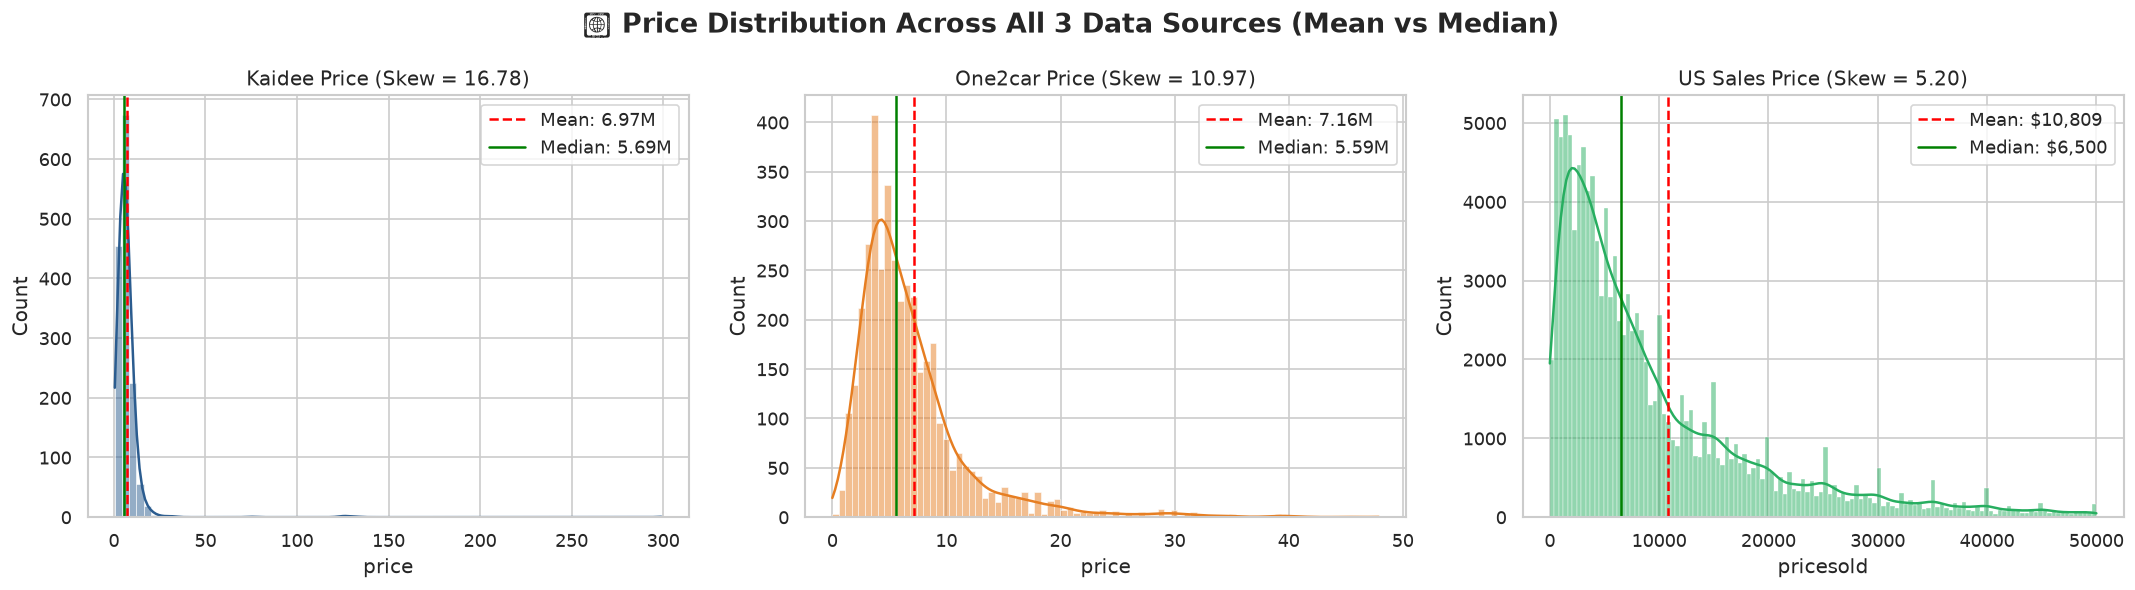

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("🔍 Price Distribution Across All 3 Data Sources (Mean vs Median)", fontsize=16, fontweight="bold")

# Kaidee
k_price = df_kaidee_raw['price'].apply(lambda x: float(re.sub(r'[^\d]', '', str(x))) if pd.notna(x) and re.sub(r'[^\d]', '', str(x))!='' else np.nan).dropna()
sns.histplot(k_price/1e5, kde=True, ax=axes[0], color="#2b5c8f")
axes[0].axvline(k_price.mean()/1e5, color="red", linestyle="--", label=f"Mean: {k_price.mean()/1e5:.2f}M")
axes[0].axvline(k_price.median()/1e5, color="green", linestyle="-", label=f"Median: {k_price.median()/1e5:.2f}M")
axes[0].set_title(f"Kaidee Price (Skew = {k_price.skew():.2f})")
axes[0].legend()

# One2car
o_price = df_one2car_raw['price'].apply(lambda x: float(re.sub(r'[^\d]', '', str(x))) if pd.notna(x) and re.sub(r'[^\d]', '', str(x))!='' else np.nan).dropna()
sns.histplot(o_price[o_price<5e6]/1e5, kde=True, ax=axes[1], color="#e67e22")
axes[1].axvline(o_price.mean()/1e5, color="red", linestyle="--", label=f"Mean: {o_price.mean()/1e5:.2f}M")
axes[1].axvline(o_price.median()/1e5, color="green", linestyle="-", label=f"Median: {o_price.median()/1e5:.2f}M")
axes[1].set_title(f"One2car Price (Skew = {o_price.skew():.2f})")
axes[1].legend()

# US Sales
u_price = df_us_raw['pricesold'].dropna()
sns.histplot(u_price[u_price<=50000], kde=True, ax=axes[2], color="#27ae60")
axes[2].axvline(u_price.mean(), color="red", linestyle="--", label=f"Mean: ${u_price.mean():,.0f}")
axes[2].axvline(u_price.median(), color="green", linestyle="-", label=f"Median: ${u_price.median():,.0f}")
axes[2].set_title(f"US Sales Price (Skew = {u_price.skew():.2f})")
axes[2].legend()

plt.tight_layout()
plt.show()